<a href="https://colab.research.google.com/github/tonHS/Canadian_Real_Estate_Stats/blob/main/Canadian_Housing_Stats.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [93]:
# ============================================================================
# Install Dependencies and Packages
# ============================================================================
!pip install stats-can openpyxl

import pandas as pd
import requests
import zipfile
from io import BytesIO
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from datetime import datetime

In [94]:
# ============================================================================
# SETUP: Create directory
# ============================================================================
print(">>> ENTERING SETUP")

data_dir = Path('data')
data_dir.mkdir(exist_ok=True)
outputs_dir = Path('outputs')
outputs_dir.mkdir(exist_ok=True)

>>> ENTERING SETUP


In [95]:
# ============================================================================
# FETCH: CMA Rental Stats Data
# ============================================================================
print(">>> ENTERING: CMA Rental Data Fetch")
print("=" * 80)
print("FETCHING CMA RENTAL DATA FROM STATISTICS CANADA")
print("=" * 80)

TABLE_ID = "46100092"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_rents = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_rents):,} rows, {len(df_rents.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'cma_rents_raw.csv'
df_rents.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> CMA Employment Data Fetch COMPLETE")

df_rents.head()

>>> ENTERING: CMA Rental Data Fetch
FETCHING CMA RENTAL DATA FROM STATISTICS CANADA

📥 Downloading data from Statistics Canada (Table 46100092)...
✓ Data loaded: 8,627 rows, 16 columns
✓ Raw data saved to: data/cma_rents_raw.csv
>>> CMA Employment Data Fetch COMPLETE


,REF_DATE,GEO,DGUID,Rental unit type,Estimates,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,2019-01,All census metropolitan areas,NaN,House - 3 or more bedrooms,Average asking rent,Dollars,81,units,0,v1869780581,43.7.1,2420.0,NaN,NaN,NaN,0
1,2019-01,All census metropolitan areas,NaN,Apartment - No bedroom,Average asking rent,Dollars,81,units,0,v1869780582,43.1.1,1090.0,NaN,NaN,NaN,0
2,2019-01,All census metropolitan areas,NaN,Apartment - 1 bedroom,Average asking rent,Dollars,81,units,0,v1869780583,43.2.1,1300.0,NaN,NaN,NaN,0
3,2019-01,All census metropolitan areas,NaN,Apartment - 2 bedrooms,Average asking rent,Dollars,81,units,0,v1869780584,43.3.1,1520.0,NaN,NaN,NaN,0
4,2019-01,All census metropolitan areas,NaN,Apartment - 3 or more bedrooms,Average asking rent,Dollars,81,units,0,v1869780585,43.4.1,1850.0,NaN,NaN,NaN,0


In [96]:
# ============================================================================
# PROCESS: CMA Rental Data
# ============================================================================

# Filter for the rent for studio, 1B and 2B apartments nationally and in City Stats Dashboard's 13 CMAs

dashboard_cmas = [
    'All census metropolitan areas',
    'Toronto, Census metropolitan area (CMA)',
    'Montréal, Census metropolitan area (CMA)',
    'Vancouver, Census metropolitan area (CMA)',
    'Calgary, Census metropolitan area (CMA)',
    'Edmonton, Census metropolitan area (CMA)',
    'Ottawa-Gatineau, Ontario/Quebec, Census metropolitan area (CMA)',
    'Winnipeg, Census metropolitan area (CMA)',
    'Québec, Census metropolitan area (CMA)',
    'Hamilton, Census metropolitan area (CMA)',
    'Halifax, Census metropolitan area (CMA)',
    'Saskatoon, Census metropolitan area (CMA)',
    'Fredericton, Census metropolitan area (CMA)',
    "St. John's, Census metropolitan area (CMA)"
]


# Filter df_jobs for the dashboard CMAs, employment and unemployment rate
df_rents_filtered = df_rents[
    (df_rents['GEO'].isin(dashboard_cmas)) &
    (df_rents['Rental unit type'].isin(['Apartment - No bedroom', 'Apartment - 1 bedroom', 'Apartment - 2 bedrooms', 'Room'])) &
    (df_rents['Estimates'] == 'Average asking rent') &
    (df_rents['REF_DATE'] == df_rents['REF_DATE'].max()) # This is quarterly data so check syntax if an error
].copy()

# Select relevant columns
df_rents_filtered = df_rents_filtered[[
    'REF_DATE',
    'GEO',
    'Rental unit type',
    'Estimates',
    'VALUE'
]].copy()

print(f"Filtered housing data for {len(dashboard_cmas)} dashboard CMAs for the most recent month.")
print(f"Data loaded: {len(df_rents_filtered):,} rows, {len(df_rents_filtered.columns)} columns.")

# Table 1: CMA rents for studio, 1B and 2B, 2026. Rows: GEO; Columns: Value for Each Rental Unit Type; Title(all): Estimates, Avg Asking Rent, 2024

df_rents_filtered.head(5)

Filtered housing data for 14 dashboard CMAs for the most recent month.
Data loaded: 51 rows, 5 columns.


,REF_DATE,GEO,Rental unit type,Estimates,VALUE
8329,2026-01,All census metropolitan areas,Apartment - No bedroom,Average asking rent,1420.0
8330,2026-01,All census metropolitan areas,Apartment - 1 bedroom,Average asking rent,1740.0
8331,2026-01,All census metropolitan areas,Apartment - 2 bedrooms,Average asking rent,2150.0
8335,2026-01,"St. John's, Census metropolitan area (CMA)",Apartment - No bedroom,Average asking rent,NaN
8336,2026-01,"St. John's, Census metropolitan area (CMA)",Apartment - 1 bedroom,Average asking rent,1250.0


In [97]:
# ============================================================================
# FETCH: Income Data
# ============================================================================
print(">>> ENTERING: Income Data Fetch")
print("=" * 80)
print("FETCHING INCOME DATA FROM STATISTICS CANADA")
print("=" * 80)

TABLE_ID = "11100190"
download_url = f"https://www150.statcan.gc.ca/n1/tbl/csv/{TABLE_ID}-eng.zip"

print(f"\n📥 Downloading data from Statistics Canada (Table {TABLE_ID})...")
response = requests.get(download_url, timeout=30)
response.raise_for_status()

with zipfile.ZipFile(BytesIO(response.content)) as zip_file:
    csv_files = [f for f in zip_file.namelist() if f.endswith('.csv')]
    csv_filename = csv_files[0]
    with zip_file.open(csv_filename) as csv_file:
        df_income = pd.read_csv(csv_file)

print(f"✓ Data loaded: {len(df_income):,} rows, {len(df_income.columns)} columns")

# Save raw data
raw_data_path = data_dir / 'regional_income_raw.csv'
df_income.to_csv(raw_data_path, index=False)
print(f"✓ Raw data saved to: {raw_data_path}")
print(">>> Regional Income Data Fetch COMPLETE")

df_income.head(5)

>>> ENTERING: Income Data Fetch
FETCHING INCOME DATA FROM STATISTICS CANADA

📥 Downloading data from Statistics Canada (Table 11100190)...
✓ Data loaded: 253,680 rows, 16 columns
✓ Raw data saved to: data/regional_income_raw.csv
>>> Regional Income Data Fetch COMPLETE


,REF_DATE,GEO,DGUID,Income concept,Economic family type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
0,1976,Canada,2021A000011124,Number of persons,Economic families and persons not in an econom...,Number,223,units,0,v96411791,1.1.1,23064300.0,NaN,NaN,NaN,0
1,1976,Canada,2021A000011124,Number of persons,Economic families,Number,223,units,0,v96411792,1.1.2,21041800.0,NaN,NaN,NaN,0
2,1976,Canada,2021A000011124,Number of persons,Senior families,Number,223,units,0,v96411793,1.1.3,1684700.0,NaN,NaN,NaN,0
3,1976,Canada,2021A000011124,Number of persons,Senior couples,Number,223,units,0,v96411794,1.1.4,932800.0,NaN,NaN,NaN,0
4,1976,Canada,2021A000011124,Number of persons,Other senior families,Number,223,units,0,v96411795,1.1.5,751900.0,NaN,NaN,NaN,0


In [98]:
#####################################################################################################################################
# Processing Regional Income Data
####################################################################################################################################

df_income_filtered = df_income[
    (df_income['Income concept'].isin(['Average total income', 'Median total income', 'Average after-tax income', 'Median after-tax income'])) &
    (df_income['REF_DATE'] == df_income['REF_DATE'].max()) &
    (df_income['Economic family type'].isin(['Economic families and persons not in an economic family', 'Economic families', 'Persons not in an economic family']))
].copy()


df_income_filtered = df_income_filtered[
    ['REF_DATE', 'GEO', 'Income concept', 'Economic family type', 'VALUE']
].copy()

print(f"✓ Data loaded: {len(df_income_filtered):,} rows, {len(df_income_filtered.columns)} columns")

df_income_filtered.head(5)


✓ Data loaded: 300 rows, 5 columns


,REF_DATE,GEO,Income concept,Economic family type,VALUE
247800,2024,Canada,Average total income,Economic families and persons not in an econom...,115000.0
247801,2024,Canada,Average total income,Economic families,153400.0
247813,2024,Canada,Average total income,Persons not in an economic family,57800.0
247820,2024,Canada,Median total income,Economic families and persons not in an econom...,86000.0
247821,2024,Canada,Median total income,Economic families,125600.0


In [99]:
####################################################################################################################################
# Processing Regional Income Data for Median after-tax, all households
####################################################################################################################################

# Making a smaller table of household median after-tax income for each CMA with available data, for the purposes of comparision with CMA rental data
# 'Households' seem colloquial equivalent to stats terminology 'economic families and persons not in economic families'

df_median_income = df_income_filtered[
    (df_income_filtered['Income concept'] == 'Median after-tax income') &
    (df_income_filtered['Economic family type'] == 'Economic families and persons not in an economic family')
    # (df_income_filtered['GEO'].isin(['Canada', 'Québec, Quebec', 'Montréal, Quebec','Ottawa-Gatineau, Ontario/Quebec','Toronto, Ontario','Winnipeg, Manitoba', 'Calgary, Alberta','Edmonton, Alberta', 'Vancouver, British Columbia']))
].copy()

# Table 2: Regional Household Income, 2024 Constant Dollars. Rows: GEO, Column: Median after-tax income - VALUE; Title(all): Household Median after-tax income (Economic families and those not in economic families)

print(f"✓ Data loaded: {len(df_median_income):,} rows, {len(df_median_income.columns)} columns")
df_median_income.head(5)

✓ Data loaded: 25 rows, 5 columns


,REF_DATE,GEO,Income concept,Economic family type,VALUE
247900,2024,Canada,Median after-tax income,Economic families and persons not in an econom...,75500.0
248140,2024,Atlantic provinces,Median after-tax income,Economic families and persons not in an econom...,65200.0
248380,2024,Newfoundland and Labrador,Median after-tax income,Economic families and persons not in an econom...,68000.0
248620,2024,Prince Edward Island,Median after-tax income,Economic families and persons not in an econom...,65900.0
248860,2024,Nova Scotia,Median after-tax income,Economic families and persons not in an econom...,64200.0


In [100]:
####################################################################################################################################
# Processing Regional Income Data for Singles
####################################################################################################################################

# Making a smaller table of household median after-tax income for singles
# 'Singles' being the colloquial equivalent to 'personsn not in an economic family'

df_singles_income = df_income[
    (df_income['Income concept'] == 'Median after-tax income') &
    (df_income['REF_DATE'] == df_income['REF_DATE'].max()) &
    (df_income['Economic family type'] == 'Persons not in an economic family')
].copy()

# Table 3: Singles Regional Household Income, 2024 Constant Dollars. Rows: GEO, Column: Median after-tax income - VALUE; Title(all): Household Median after-tax income (Singles: those not in economic families)

print(f"✓ Data loaded: {len(df_singles_income):,} rows, {len(df_singles_income.columns)} columns")
df_singles_income.head(5)

✓ Data loaded: 25 rows, 16 columns


,REF_DATE,GEO,DGUID,Income concept,Economic family type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
247913,2024,Canada,2021A000011124,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412024,1.12.14,41000.0,A,NaN,NaN,0
248153,2024,Atlantic provinces,2021A00011,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412264,2.12.14,35600.0,A,NaN,NaN,0
248393,2024,Newfoundland and Labrador,2021A000210,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412504,3.12.14,33700.0,A,NaN,NaN,0
248633,2024,Prince Edward Island,2021A000211,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412744,4.12.14,36700.0,A,NaN,NaN,0
248873,2024,Nova Scotia,2021A000212,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412984,5.12.14,36300.0,B,NaN,NaN,0


In [101]:
####################################################################################################################################
# Visual for Table 1 - Avg CMA rents for studio, 1B and 2B
####################################################################################################################################

df_rents_filtered.head()

,REF_DATE,GEO,Rental unit type,Estimates,VALUE
8329,2026-01,All census metropolitan areas,Apartment - No bedroom,Average asking rent,1420.0
8330,2026-01,All census metropolitan areas,Apartment - 1 bedroom,Average asking rent,1740.0
8331,2026-01,All census metropolitan areas,Apartment - 2 bedrooms,Average asking rent,2150.0
8335,2026-01,"St. John's, Census metropolitan area (CMA)",Apartment - No bedroom,Average asking rent,NaN
8336,2026-01,"St. John's, Census metropolitan area (CMA)",Apartment - 1 bedroom,Average asking rent,1250.0


Table saved to outputs/table_1_cma_rents_pivoted.png


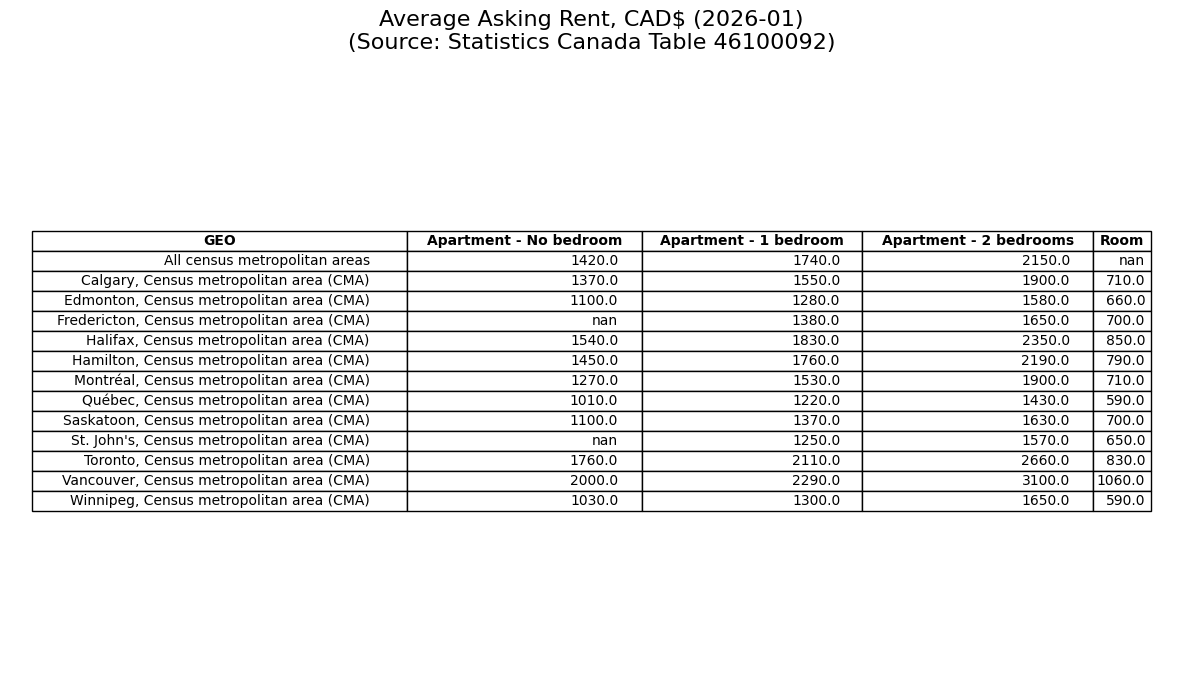

In [102]:
####################################################################################################################################
# Visual for Table 1 - Avg CMA rents for studio, 1B and 2B
####################################################################################################################################

# Pivot the DataFrame to have 'Rental unit type' as columns
df_rents_pivot = df_rents_filtered.pivot_table(
    index=['GEO'],
    columns='Rental unit type',
    values='VALUE'
).reset_index()

# Flatten the multi-level columns if created
df_rents_pivot.columns.name = None

# Rename columns for clarity (e.g., 'Apartment - No bedroom' to 'Studio Rent') if needed
# For simplicity, we'll keep the original pivoted column names for now.

# Sort the columns to ensure consistent order (optional)
df_rents_pivot = df_rents_pivot[['GEO', 'Apartment - No bedroom', 'Apartment - 1 bedroom', 'Apartment - 2 bedrooms', 'Room']]

# Extract the reference date for the title dynamically
ref_date = df_rents_filtered['REF_DATE'].iloc[0] if not df_rents_filtered.empty else 'N/A'

# Create a figure and a set of subplots
fig, ax = plt.subplots(figsize=(15, 8)) # Adjusted figure size for more columns

# Hide the axes
ax.axis('off')
ax.axis('tight')

# Add the title to the plot, including the dynamic reference date and source
ax.set_title(f'Average Asking Rent, CAD$ ({ref_date})\n(Source: Statistics Canada Table 46100092)', fontsize=16, pad=10)

# Create the table
table = ax.table(cellText=df_rents_pivot.values, colLabels=df_rents_pivot.columns, loc='center')

# Auto-adjust column widths
table.auto_set_column_width(col=list(range(len(df_rents_pivot.columns))))

# Set font size and scale for better readability
table.set_fontsize(10)
table.scale(1.2, 1.2)

# Make column headers bold
for (row, col), cell in table.get_celld().items():
    if row == 0:  # This is the header row
        cell.set_text_props(weight='bold')

# Save the table as a PNG image
output_path = outputs_dir / 'table_1_cma_rents_pivoted.png' # Changed output filename
plt.savefig(output_path, bbox_inches='tight', dpi=300)
print(f"Table saved to {output_path}")

plt.show()

In [103]:
####################################################################################################################################
# Visual for Table 2 - Economic Families and Singles, Regional Median After-tax Income
####################################################################################################################################

df_median_income.head()

,REF_DATE,GEO,Income concept,Economic family type,VALUE
247900,2024,Canada,Median after-tax income,Economic families and persons not in an econom...,75500.0
248140,2024,Atlantic provinces,Median after-tax income,Economic families and persons not in an econom...,65200.0
248380,2024,Newfoundland and Labrador,Median after-tax income,Economic families and persons not in an econom...,68000.0
248620,2024,Prince Edward Island,Median after-tax income,Economic families and persons not in an econom...,65900.0
248860,2024,Nova Scotia,Median after-tax income,Economic families and persons not in an econom...,64200.0


Table saved to outputs/table_2_median_income.png


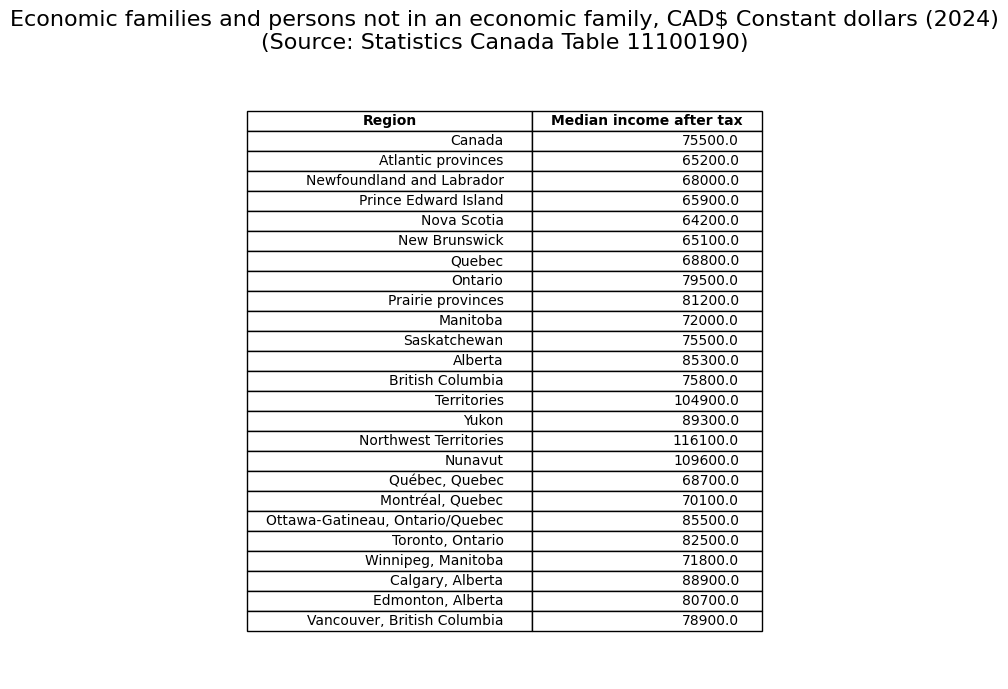

In [104]:
####################################################################################################################################
# Visual for Table 2 - Economic Families and Singles, Regional Median After-tax Income
####################################################################################################################################

# Extract the reference date for the title dynamically
ref_date_median_income = df_median_income['REF_DATE'].iloc[0] if not df_median_income.empty else 'N/A'

# Prepare the DataFrame for display by dropping 'Income concept' and 'Economic family type'
df_median_income_display = df_median_income.drop(columns=['Income concept', 'Economic family type', 'REF_DATE']).copy()

# Rename columns as requested
df_median_income_display = df_median_income_display.rename(columns={'GEO': 'Region', 'VALUE': 'Median income after tax'})

# Create a figure and a set of subplots
fig_median_income, ax_median_income = plt.subplots(figsize=(12, 8)) # Adjust figure size as needed

# Hide the axes
ax_median_income.axis('off')
ax_median_income.axis('tight')

# Add the title to the plot, including the dynamic reference date and source
ax_median_income.set_title(f'Economic families and persons not in an economic family, CAD$ Constant dollars ({ref_date_median_income})\n(Source: Statistics Canada Table 11100190)', fontsize=16, pad=10)

# Create the table
table_median_income = ax_median_income.table(cellText=df_median_income_display.values, colLabels=df_median_income_display.columns, loc='center')

# Auto-adjust column widths
table_median_income.auto_set_column_width(col=list(range(len(df_median_income_display.columns))))

# Set font size and scale for better readability
table_median_income.set_fontsize(10)
table_median_income.scale(1.2, 1.2)

# Make column headers bold
for (row, col), cell in table_median_income.get_celld().items():
    if row == 0:  # This is the header row
        cell.set_text_props(weight='bold')

# Save the table as a PNG image
output_path_median_income = outputs_dir / 'table_2_median_income.png'
plt.savefig(output_path_median_income, bbox_inches='tight', dpi=300)
print(f"Table saved to {output_path_median_income}")

plt.show()

In [105]:
####################################################################################################################################
# Visual for Table 3 - Singles, Regional Median After-tax Income
####################################################################################################################################

df_singles_income.head(5)

,REF_DATE,GEO,DGUID,Income concept,Economic family type,UOM,UOM_ID,SCALAR_FACTOR,SCALAR_ID,VECTOR,COORDINATE,VALUE,STATUS,SYMBOL,TERMINATED,DECIMALS
247913,2024,Canada,2021A000011124,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412024,1.12.14,41000.0,A,NaN,NaN,0
248153,2024,Atlantic provinces,2021A00011,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412264,2.12.14,35600.0,A,NaN,NaN,0
248393,2024,Newfoundland and Labrador,2021A000210,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412504,3.12.14,33700.0,A,NaN,NaN,0
248633,2024,Prince Edward Island,2021A000211,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412744,4.12.14,36700.0,A,NaN,NaN,0
248873,2024,Nova Scotia,2021A000212,Median after-tax income,Persons not in an economic family,2024 constant dollars,455,units,0,v96412984,5.12.14,36300.0,B,NaN,NaN,0


Table saved to outputs/table_3_singles_income.png


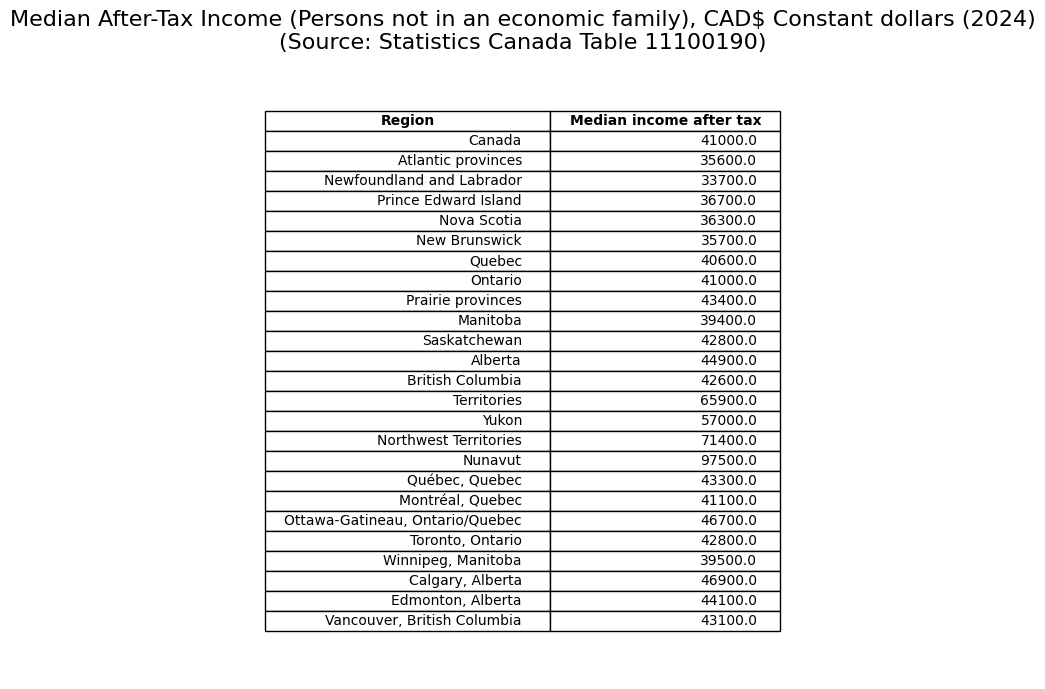

In [106]:
# Extract the reference date for the title dynamically
ref_date_singles_income = df_singles_income['REF_DATE'].iloc[0] if not df_singles_income.empty else 'N/A'

# Prepare the DataFrame for display by dropping 'Income concept' and 'Economic family type' and 'REF_DATE'
df_singles_income_display = df_singles_income.drop(columns=['Income concept', 'Economic family type', 'REF_DATE', 'DGUID', 'UOM', 'UOM_ID', 'SCALAR_FACTOR', 'SCALAR_ID', 'VECTOR', 'COORDINATE', 'STATUS', 'SYMBOL', 'TERMINATED', 'DECIMALS']).copy()

# Rename columns as requested
df_singles_income_display = df_singles_income_display.rename(columns={'GEO': 'Region', 'VALUE': 'Median income after tax'})

# Create a figure and a set of subplots
fig_singles_income, ax_singles_income = plt.subplots(figsize=(12, 8)) # Adjust figure size as needed

# Hide the axes
ax_singles_income.axis('off')
ax_singles_income.axis('tight')

# Add the title to the plot, including the dynamic reference date and source
ax_singles_income.set_title(f'Median After-Tax Income (Persons not in an economic family), CAD$ Constant dollars ({ref_date_singles_income})\n(Source: Statistics Canada Table 11100190)', fontsize=16, pad=10)

# Create the table
table_singles_income = ax_singles_income.table(cellText=df_singles_income_display.values, colLabels=df_singles_income_display.columns, loc='center')

# Auto-adjust column widths
table_singles_income.auto_set_column_width(col=list(range(len(df_singles_income_display.columns))))

# Set font size and scale for better readability
table_singles_income.set_fontsize(10)
table_singles_income.scale(1.2, 1.2)

# Make column headers bold
for (row, col), cell in table_singles_income.get_celld().items():
    if row == 0:  # This is the header row
        cell.set_text_props(weight='bold')

# Save the table as a PNG image
output_path_singles_income = outputs_dir / 'table_3_singles_income.png'
plt.savefig(output_path_singles_income, bbox_inches='tight', dpi=300)
print(f"Table saved to {output_path_singles_income}")

plt.show()

In [107]:
# Quickly spotcheck the above to ensure no numbers off from raw
# Fix table titles to show correct source numbers
# Get current dollar earnings from SEPH or LMA
# Pull and generate similar data
# Compare them to rents to generate a % and rank from green-yellow-red in terms of ability to live while adapting to lay-off, recent grad, bad economy